## TAREA MOTIVACIONAL

### Carla Herrera Vidal

- Realizar un Exploratory Data Analysis en el dataset Titanic.
- Este debe ser subido a un repositorio público propio.
- Enviar el link al repositorio por mensaje interno de Ucampus.


### Pasos para realizar un análisis exploratorio de datos según [Simplilearn](https://encrypted-vtbn1.gstatic.com/video?q=tbn:ANd9GcR1noIHTOls9muXa0vrYCU4GL9bqcyTydTupbkyd8TMjYxhUxJA)

1. Carga de datos: importar datos (CSV, Excel, bases de datos) y examinar su estructura (filas, columnas, tipos de datos).
2. Limpieza de datos: identificar y gestionar los valores que faltan (introducirlos o eliminarlos), borrar duplicados y tratar los valores atípicos que podrían sesgar el análisis.
3. Estadística descriptiva: calcular estadísticas resumidas como la media, la mediana, la desviación estándar, el mínimo y el máximo para comprender la distribución de los datos.

Para efectos del dataset Titanic que tiene 3 archivos csv; train, test y gender_submission se usará el de train ya que este es el que tiene la información en bruto de los pasajeros y del viaje en sí.

In [3]:
import sys
print(sys.executable)

c:\Users\carla\miniconda3\envs\Ejercicios\python.exe


In [15]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()

#este sirve para verificar en cuantos pasajeros falta información en cada columna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
#en la parte de la cabina faltan 687 datos, entonces se puede rellenar con desconocido pq este es string
df['Cabin']= df['Cabin'].fillna('Unknown')
#en la parte de la embarcacion faltan 2 datos, entonces se puede rellenar con desconocido pq este es string
df['Embarked']= df['Embarked'].fillna('Unknown')

In [18]:
#verificar duplicados
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [21]:
#estandarizar ortografia de los nombres de las columnas
df['Sex'] = df['Sex'].str.lower()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


## Estadística descriptiva

In [31]:
#promedio de gente que sobrevivió 
prom_survived = df['Survived'].mean()

print(f"El promedio de gente que sobrevivió es: {prom_survived*100:.2f}%")
print(f"Como la cantidad de gente en total reportada en el dataset es de {len(df)}, entonces el número de sobrevivientes es de {int(prom_survived*len(df))} personas. Dejando entonces que la cantidad de fallecidos reportados es de {len(df) - int(prom_survived*len(df))} personas.")

#promedio de gente que sobrevivió por clase 
prom_survived_pclass = df.groupby('Pclass')['Survived'].mean()*100
print("Porcentaje de supervivencia por clase:")
print(prom_survived_pclass)
print("La mayor gente viva reportada fueron de primer clase, suponiendo que tenían preferencia para escapar y usar botes salvavidas, mientras que la menor gente viva reportada fueron de tercer clase, suponiendo que tenían menos preferencia para escapar")

#promedio de gente que sobrevivió por sexo en general
prom_survived_sex = df.groupby('Sex')['Survived'].mean()*100
print("Porcentaje de supervivencia por sexo:")
print(prom_survived_sex)
print("La mayor gente viva reportada fueron mujeres, suponiendo que tenían preferencia para escapar y usar botes salvavidas ya que las políticas de escape en emergencias busca priorizar a niños y mujeres.")

#promedio de gente que sobrevivió por sexo en clases sociales
prom_survived_sex_pclass = df.groupby(['Pclass', 'Sex'])['Survived'].mean()*100
print("Porcentaje de supervivencia por sexo y clase:")  
print(prom_survived_sex_pclass)
print("Por clase social, la mayor gente viva reportada fueron mujeres de primer clase con casi todas vivas, mientras que los hombres de esa clase social sosbrevivieron bastante menos que la mitad. Para 2da clase las mujeres también fueron las con más casos vivos pero en hombres estos alcanzaron a salvarse apenas el 15 por ciento de ellos. Y finalmente para tercera clase, la más pobre solo la mitad de las mujeres sobrevivieron y apenas el 13 por ciento de los hombres sobrevivieron, lo que muestra que la clase social también tuvo un impacto en la supervivencia de las personas.")

#precio de los pasajes
prom_fare = df['Fare'].mean()
print(f"El precio promedio de los pasajes es: ${prom_fare:.2f}")
mediana_fare = df['Fare'].median()
print(f"La mediana del precio de los pasajes es: ${mediana_fare:.2f}")
print("Según la campana de Gauss y su simetrías, como el promedio es mayor que la mediana, entonces la distribución de los precios de los pasajes es asimétrica a la derecha indicando que mientras más cantidad de gente pagó precios bajos, hubo una minoría que pagó precios extremadamente altos, lo que hace subir el promedio por encima de la mediana.")

El promedio de gente que sobrevivió es: 38.38%
Como la cantidad de gente en total reportada en el dataset es de 891, entonces el número de sobrevivientes es de 342 personas. Dejando entonces que la cantidad de fallecidos reportados es de 549 personas.
Porcentaje de supervivencia por clase:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
La mayor gente viva reportada fueron de primer clase, suponiendo que tenían preferencia para escapar y usar botes salvavidas, mientras que la menor gente viva reportada fueron de tercer clase, suponiendo que tenían menos preferencia para escapar
Porcentaje de supervivencia por sexo:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
La mayor gente viva reportada fueron mujeres, suponiendo que tenían preferencia para escapar y usar botes salvavidas ya que las políticas de escape en emergencias busca priorizar a niños y mujeres.
Porcentaje de supervivencia por sexo y clase:
Pclass  Sex   
1       

### Visualización

In [ ]:
%pip install matplotlib seaborn

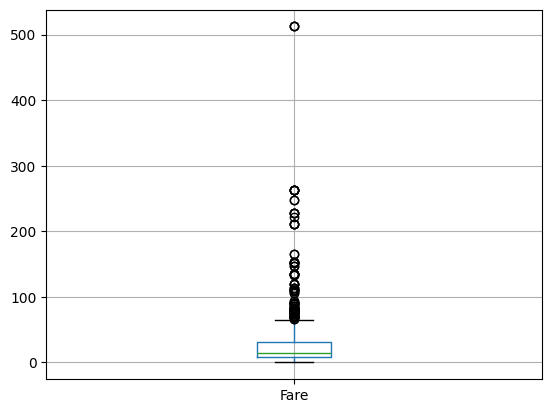

In [35]:
import matplotlib.pyplot as plt
df.boxplot(column='Fare')
plt.show()


El boxplot de arriba demuestra la desigualdad de pasajes y sus tarifas para los pasajeros del Titanic, la caja está casi cerca del 50, es decir la mitad de la gente y hacia abajo dando a entender que la mayoría de los pasajeros era de escasos recursos por el precio del pasaje. Además los outliers que se extienden más allá del máximo se asume que son los pasajes más caros pagados por los de primera clase, siendo el más alejado de 500 y algo. La diferencia es muy grande entre el máximo y mínimo, además que la mediana al estar cerca del valor más bajo indica una distribución de datos sesgada a la derecha.

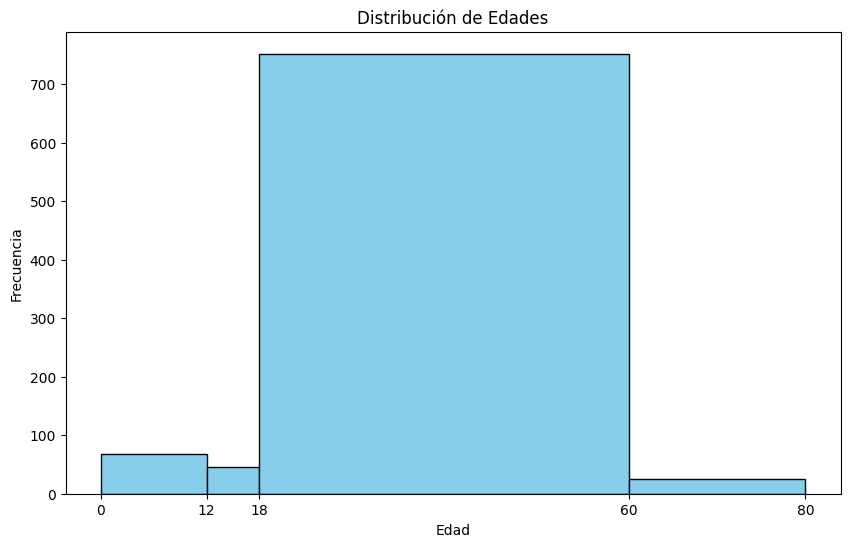

In [39]:
#histograma separado por edad (niños (0-12), adolescentes (13-17), adultos (18-59) y ancianos (60+))
plt.hist(df['Age'], bins=[0, 12, 18, 60, 80], color = 'skyblue', edgecolor='black')
plt.title('Distribución de Edades')
plt.xlabel('Edad')  
plt.ylabel('Frecuencia')
plt.xticks([0, 12, 18, 60, 80])
plt.show()

El histograma muestra que la mayor csntidad de pasajeros independiente de su clase social eran adultos entre 18 y 60 años, mientras que menores de edad <18 años, eran menos de 100.

In [45]:
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


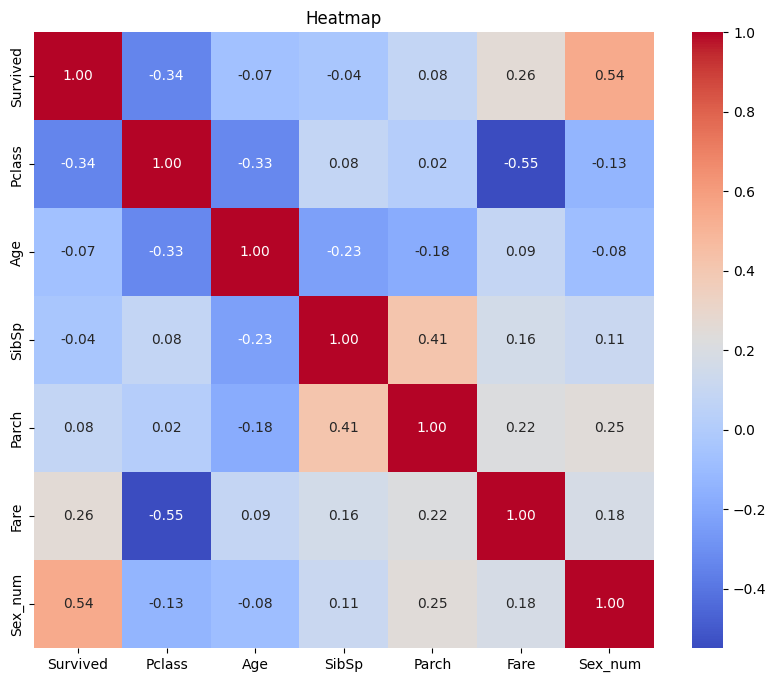

In [47]:
#mapa de calor pa ver que está relacionado con qué
#la columna Sex está en string, así que se le agregará otra columna al lado con números para poder hacer el mapa de calor, 1= mujer y 0= hombre

df['Sex_num']=df['Sex'].map({'female': 1, 'male':0})
columnas_pal_heatmap= ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_num']
df_heatmap = df[columnas_pal_heatmap]

heatmap = df_heatmap.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Heatmap')
plt.show()

En el heatmap las correlacione fueron bastante bajas, con algunas negativas lo cual significa una relación inversa. Por ejemplo la clase y el ticket que pagó, una sube y otra baja. Pero como en Pclass 1=primera clase, 2=segunda clase y 3=tercera clase la 1 es la que pagó más. Por lo tanto, a medida que el número de clase aumenta hacia la tercera (3), el valor del ticket disminuye, resultando en una relación inversamente proporcional. También hay correlaciones positivas, donde destaca la de Sex_num con Survived (0.54). Este es el número más alto del gráfico y confirma matemáticamente que ser mujer fue el factor que más aseguró la vida post hundimiento. También hay una relación de 0.26 entre Fare y Survived, lo que nos dice que el tener dinero previo sí ayudó a subir a los botes o cualquier otra manera con que sobrevivieron los pasajeros. Y finalmente hay cruces que no tienen muhco que ver como el de Pclass y Parch (0.02) esto significa que la clase social no tenía nada que ver con si viajabas con papás o hijos. 